In [1]:
include("MiniCollectiveSpins.jl")
using PyPlot
using Statistics
using JLD2
using ProgressBars

### Define the system

In [2]:
# Parameters
N = 10
sat = [0.1:5:35.1;]
pathname_density_distrib = "Groundstate_Bext_90_deg_as_98.h5"
@load "Density_distributions\\$(pathname_density_distrib[1:end-3]).jld2" CS_densities_cuts_interpolated_norm
n_list = CS_densities_cuts_interpolated_norm[1:100:length(CS_densities_cuts_interpolated_norm)]

# Quantization axis along z
e = [0, 0, 1.]

# Constants
λ = 421e-9
γ = 32.7e6 # In Hz
@load "op_list/op_list_$N.jdl2" op_list;

# Plots of the time evolution

0.0%┣                                               ┫ 0/8 [00:01<00:-11, -1s/it]
12.5%┣█████▍                                     ┫ 1/8 [00:03<Inf:Inf, InfGs/it]
37.5%┣██████████████████                              ┫ 3/8 [00:03<00:08, 2s/it]
62.5%┣██████████████████████████████                  ┫ 5/8 [00:03<00:02, 1it/s]
87.5%┣██████████████████████████████████████████      ┫ 7/8 [00:03<00:01, 2it/s]
100.0%┣███████████████████████████████████████████████┫ 8/8 [00:03<00:00, 2it/s]
100.0%┣███████████████████████████████████████████████┫ 8/8 [00:03<00:00, 2it/s]


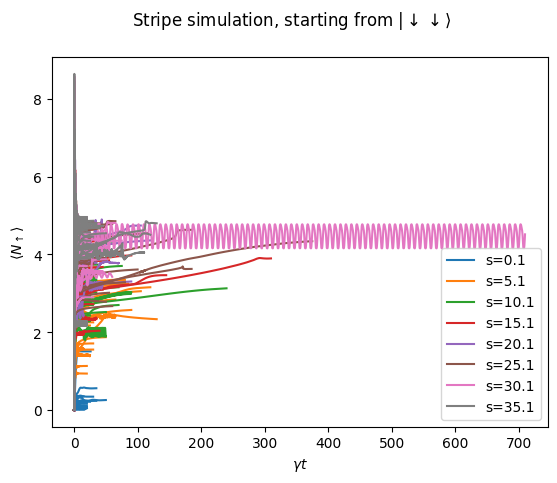

In [3]:
close("all")
fig, ax = subplots() 

list_t_N, popup_t_N, sol_t_N = [], [], []

for (i, s) in ProgressBar(enumerate(sat))
    line = []
    @load "solutions/sol_N_$(N)_sat_$(sat[i])_stripe_distribution_$(pathname_density_distrib).jld2" sol_tasks
    list_t, popup_t, sol_t =  [vcat([st[i] for st in sol_tasks]...) for i = 1:3]
    push!(list_t_N, list_t), push!(popup_t_N, popup_t), push!(sol_t_N, sol_t)
    for j in 1:length(popup_t)
        if line == []
            line, = ax.plot(list_t[j], popup_t[j], label="s=$(s)")
        else
            ax.plot(list_t[j], popup_t[j], color=line.get_color()) # marker="o", markersize=1,
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  N_{\uparrow} \rangle $")
ax.legend()

suptitle("Stripe simulation, starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

0.0%┣                                                ┫ 0/8 [00:00<00:00, -0s/it]
12.5%┣█████▍                                     ┫ 1/8 [00:00<Inf:Inf, InfGs/it]
50.0%┣███████████████████████▌                       ┫ 4/8 [00:00<00:00, 25it/s]
87.5%┣█████████████████████████████████████████▏     ┫ 7/8 [00:00<00:00, 33it/s]
100.0%┣██████████████████████████████████████████████┫ 8/8 [00:00<00:00, 35it/s]
100.0%┣██████████████████████████████████████████████┫ 8/8 [00:00<00:00, 35it/s]


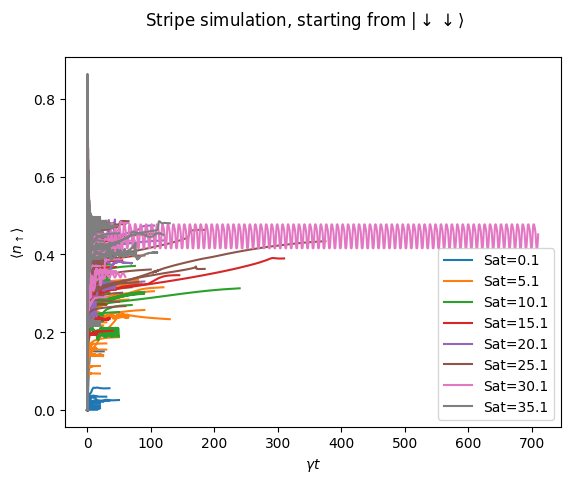

In [4]:
close("all")
fig, ax = subplots()

for (i, s) in ProgressBar(enumerate(sat))
    line = []
    for j in 1:length(popup_t_N[i])
        if line == []
            line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, label="Sat=$(s)")
        else
            ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, color=line.get_color()) # marker="o", markersize=1,
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("Stripe simulation, starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

### Density dependancy

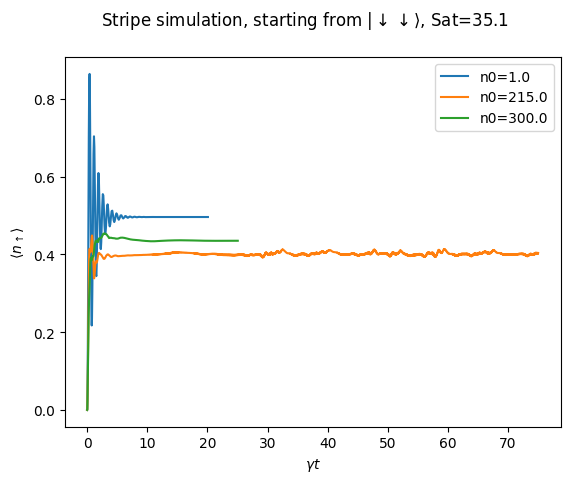

In [5]:
close("all")
fig, ax = subplots()

i = length(sat)
line = []
for j in 1:10:length(popup_t_N[i])
    line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, label="n0=$(round(n_list[j]))")
end


ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("Stripe simulation, starting from "*L"$|\downarrow \downarrow \rangle $"*", Sat=$(sat[i])")
pygui(false); gcf();
# pygui(true); show()

# Mean of the SS

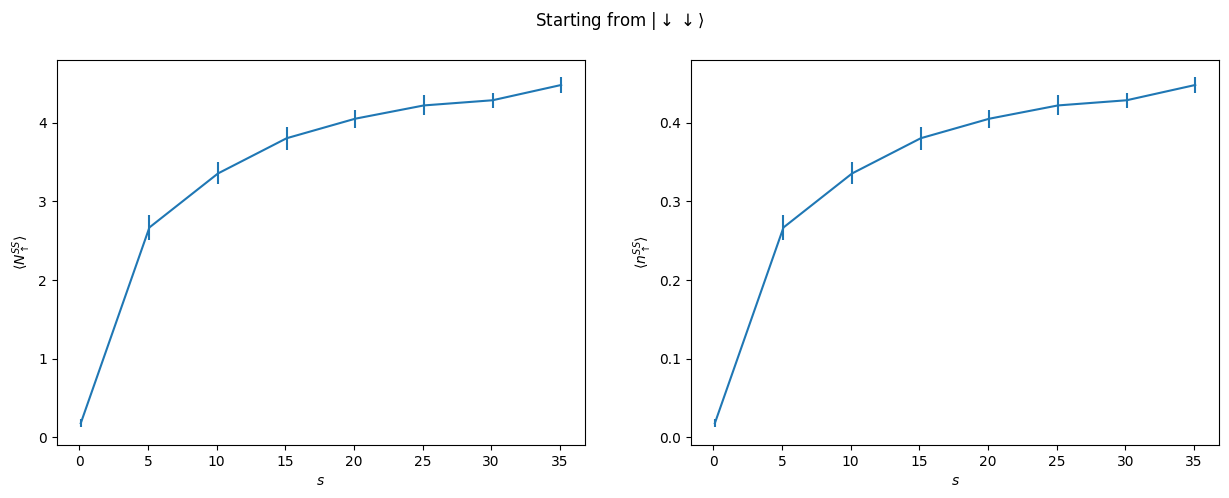

In [6]:
mean_SS = mean.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i])] for i = 1:length(popup_t_N)])
std_SS = std.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i])] for i = 1:length(popup_t_N)])

fig, axes = subplots(1, 2, figsize = (15, 5))
axes[1].errorbar(sat, mean_SS, yerr=std_SS ./ sqrt.([length(popup_t_N[i]) for i = 1:length(sat)]))
axes[1].set_xlabel(L"s")
axes[1].set_ylabel(L"$\langle  N_{\uparrow}^{SS} \rangle $")

axes[2].errorbar(sat, mean_SS./N, yerr=std_SS ./ (N .* sqrt.([length(popup_t_N[i]) for i = 1:length(sat)])))
axes[2].set_xlabel(L"s")
axes[2].set_ylabel(L"$\langle  n_{\uparrow}^{SS} \rangle $")

suptitle("Starting from "*L"$|\downarrow \downarrow \rangle $")

pygui(false); gcf();
# pygui(true); show()

# Compute $\gamma_{SE}$ from the SR SS

In [7]:
I_SE_SR_SS = zeros(ComplexF64, (length(sat), length(n_list)))

for (i, s) in enumerate(sat)
    for j in 1:length(n_list)
        @load "r0/r0_N_$(N)_n_$(n_list[j]).jdl2" r0 L
        system = SpinCollection(r0, e, gammas=1.)
        Γ_CS = GammaMatrix(system)
        
        if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
            sol_SS = sol_t_N[i][j][end]
        else
            sol_SS = sol_t_N[i][j] # Only the SS was saved
        end

        for a = 1:N
            I_SE_SR_SS[i, j] += Γ_CS[a, a]*sol_SS[a]
        end
        I_SE_SR_SS[i, j] /= N
    end
end
I_SE_SR_SS = real.(I_SE_SR_SS);

# Compute $\gamma_{SR}$ from the SR SS

In [8]:
I_SR_SR_SS = zeros(ComplexF64, (length(sat), length(n_list)))

for (i, s) in enumerate(sat)
    for j in 1:length(n_list)
        @load "r0/r0_N_$(N)_n_$(n_list[j]).jdl2" r0 L
        system = SpinCollection(r0, e, gammas=1.)
        Γ_CS = GammaMatrix(system)
        
        if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
            sol_SS = sol_t_N[i][j][end]
        else
            sol_SS = sol_t_N[i][j] # Only the SS was saved
        end

        for a = 1:N
            for b = 1:N
                if b > a # Correlated decay
                    corr = [21*10^(floor(Int, log10(a))+1)+a, 12*10^(floor(Int, log10(b))+1)+b]
                    try
                        I_SR_SR_SS[i, j] += 2*Γ_CS[a, b]*sol_SS[findall(x->x==corr || x==reverse(corr), op_list)[1]]
                    catch
                        println("Error @ $N, r=$j, a=$a, b=$b, corr=$corr")
                    end
                end
            end
        end
        I_SR_SR_SS[i, j] /= N
    end
end
I_SR_SR_SS = real.(I_SR_SR_SS);

In [9]:
Itot = I_SE_SR_SS .+ I_SR_SR_SS;

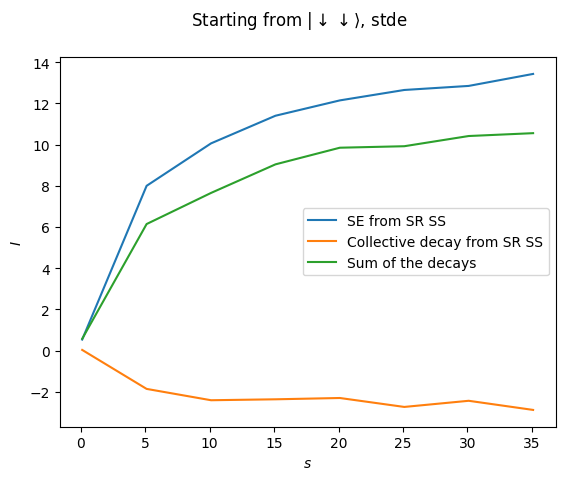

In [ ]:
close("all")
fig = subplots()

plot(sat, sum(I_SE_SR_SS, dims=2), label="SE from SR SS")
plot(sat, sum(I_SR_SR_SS, dims=2), label="Collective decay from SR SS")
plot(sat, sum(Itot, dims=2), label="Sum of the decays")

xlabel(L"s")
ylabel(L"$I$")

suptitle("Starting from "*L"$|\downarrow \downarrow \rangle $, stde")
legend()

# pygui(true); show()
pygui(false);

# Convert to photon/$m^2$

In [11]:
L_list = (N ./ n_list).^(1/2)
V_list = 6*(L_list .*λ).^2;

Itot *= γ
I_SE_SR_SS *= γ
I_SR_SR_SS *= γ

Itot_per_droplet = Itot * (1 ./ V_list)
I_SE_SR_SS_per_droplet = I_SE_SR_SS * (1 ./ V_list)
I_SR_SR_SS_per_droplet = I_SR_SR_SS * (1 ./ V_list);

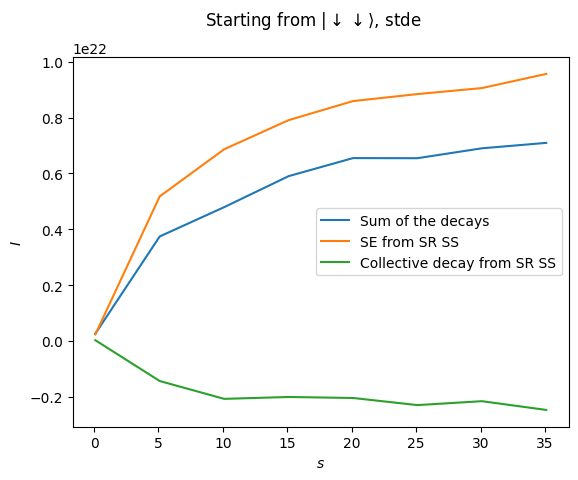

In [12]:
close("all")
fig = subplots()

plot(sat, Itot_per_droplet, label="Sum of the decays")
plot(sat, I_SE_SR_SS_per_droplet, label="SE from SR SS")
plot(sat, I_SR_SR_SS_per_droplet, label="Collective decay from SR SS")

xlabel(L"s")
ylabel(L"$I$")

suptitle("Starting from "*L"$|\downarrow \downarrow \rangle $, stde")
legend()

# pygui(true); show()
pygui(false);

In [13]:
if !isdir("Itot")
    mkdir("Itot")
end
@save "Itot/Itot_N_$(N)_Sat_$(sat)_decay_rate_up_up.jdl2" sat Itot I_SE_SR_SS I_SR_SR_SS